In [14]:
# ============================================
# Startup Cell: Mount Drive + Load Config + Verify Inputs
# ============================================

from google.colab import drive
drive.mount("/content/drive")

import os
import sys

# -------------------------------------------------
# Add project src directory to Python path
# -------------------------------------------------
PROJECT_SRC_PATH = "/content/drive/MyDrive/DIP_Project/src"

if PROJECT_SRC_PATH not in sys.path:
    sys.path.append(PROJECT_SRC_PATH)

# -------------------------------------------------
# Import project configuration
# -------------------------------------------------
from project_config import *

print("Project configuration loaded successfully.")

# -------------------------------------------------
# Construct required file paths using config
# -------------------------------------------------
TEST_FEATURES_PATH = os.path.join(METADATA_DIR, TEST_NORMALIZED_FILENAME)
SCALER_PATH = os.path.join(MODELS_DIR, SCALER_FILENAME)

# -------------------------------------------------
# Detect required model files (MLP + RBF SVM)
# -------------------------------------------------
MODEL_FILES = [f for f in os.listdir(MODELS_DIR) if f.endswith(".pkl")]

MLP_MODEL_FILE = None
RBF_MODEL_FILE = None

for f in MODEL_FILES:
    fname = f.lower()
    if "mlp" in fname:
        MLP_MODEL_FILE = f
    elif "rbf" in fname or "svm" in fname:
        RBF_MODEL_FILE = f

# -------------------------------------------------
# Verify required input files
# -------------------------------------------------
print("\nVerifying required input files...\n")

all_ok = True

# Check test features
if os.path.exists(TEST_FEATURES_PATH):
    print(f"{TEST_FEATURES_PATH}  --> OK")
else:
    print(f"{TEST_FEATURES_PATH}  --> MISSING")
    all_ok = False

# Check scaler
if os.path.exists(SCALER_PATH):
    print(f"{SCALER_PATH}  --> OK")
else:
    print(f"{SCALER_PATH}  --> MISSING")
    all_ok = False

# Check MLP model
if MLP_MODEL_FILE is not None:
    MLP_MODEL_PATH = os.path.join(MODELS_DIR, MLP_MODEL_FILE)
    print(f"{MLP_MODEL_PATH}  --> OK (MLP model detected)")
else:
    print("MLP model not found in models directory.")
    all_ok = False

# Check RBF SVM model
if RBF_MODEL_FILE is not None:
    RBF_MODEL_PATH = os.path.join(MODELS_DIR, RBF_MODEL_FILE)
    print(f"{RBF_MODEL_PATH}  --> OK (RBF SVM model detected)")
else:
    print("RBF SVM model not found in models directory.")
    all_ok = False

# -------------------------------------------------
# Final status
# -------------------------------------------------
if all_ok:
    print("\nAll required files are present. Ready to proceed.")
else:
    raise FileNotFoundError("\nOne or more required files are missing. Please check paths.")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project configuration loaded successfully.

Verifying required input files...

/content/drive/MyDrive/DIP_Project/data/metadata/test_feature_vectors_normalized.csv  --> OK
/content/drive/MyDrive/DIP_Project/models/scaler.pkl  --> OK
/content/drive/MyDrive/DIP_Project/models/MLP_128_64_32_alpha0.001.pkl  --> OK (MLP model detected)
/content/drive/MyDrive/DIP_Project/models/RBF_SVM_C100_gamma0.01.pkl  --> OK (RBF SVM model detected)

All required files are present. Ready to proceed.


In [15]:
# ============================================================
# Cell 0: Notebook Overview
# ============================================================
#
# Purpose:
# Evaluate the two final trained classifiers on the independent
# held-out test set using the normalized Digital Image
# Processing (DIP) feature vectors generated in earlier
# pipeline steps.
#
# This notebook provides the final unbiased assessment of
# classifier performance after model selection and training
# have already been completed. It uses the saved final MLP
# model and saved final RBF SVM model from Notebook 08 and
# applies each to the test set exactly once to measure
# generalization performance.
#
# ------------------------------------------------------------
# Inputs:
# ------------------------------------------------------------
# Normalized training and test datasets produced in
# Notebook 06:
#
#   - X_train
#   - y_train
#   - X_test
#   - y_test
#
# Saved model artifacts produced in Notebook 08:
#
#   - final trained MLP classifier (.pkl)
#   - final trained RBF SVM classifier (.pkl)
#   - scaler.pkl
#   - best_mlp_model_config.json
#   - best_rbf_svm_model_config.json
#   - cross_validation_results_mlp.csv
#   - cross_validation_results_rbf_svm.csv
#
# These datasets:
#   - contain the full DIP feature vectors (25 features)
#   - are normalized using training-set statistics
#   - are free of missing values
#
# ------------------------------------------------------------
# Assumptions:
# ------------------------------------------------------------
# - Feature extraction and normalization have been completed
# - Model selection and cross-validation have already been
#   completed in Notebook 08
# - The dataset is split into training and test sets only
# - The saved MLP and RBF SVM models are the final selected
#   classifiers
# - The test set has not been used for model selection or
#   tuning
#
# ------------------------------------------------------------
# Cell-by-Cell Flow:
# ------------------------------------------------------------
# Cell 1:
#   Environment setup and imports
#
# Cell 2:
#   Load normalized test data and saved model artifacts
#
# Cell 3:
#   Run sanity checks on loaded data and separate features
#   and labels
#
# Cell 4:
#   Generate class predictions and class probabilities or
#   decision scores for both classifiers on the test set
#
# Cell 5:
#   Compute final evaluation metrics for both classifiers
#
# Cell 6:
#   Generate and display the confusion matrices
#
# Cell 7:
#   Generate and display the ROC curves
#
# Cell 8:
#   Summarize final test results in tabular form
#
# Cell 9:
#   Save final evaluation outputs for documentation and
#   reporting
#
# ------------------------------------------------------------
# Outputs:
# ------------------------------------------------------------
# - Final test-set accuracy, precision, recall, F1-score,
#   and ROC-AUC for both classifiers
# - Confusion matrices
# - ROC curves
# - Summary table of final evaluation results
# - Saved evaluation outputs for reporting and project
#   documentation
#
# ------------------------------------------------------------
# Notes:
# ------------------------------------------------------------
# - This notebook performs the final independent evaluation
#   on the held-out test set
# - No model tuning or selection is performed in this notebook
# - Test results from this notebook should be treated as the
#   final performance results of the classifiers
#
# ============================================================

print("Notebook overview loaded.")


Notebook overview loaded.


In [16]:
# ============================================================
# Cell 1: Imports and Environment Setup
# ============================================================

# ------------------------------------------------------------
# Standard libraries
# ------------------------------------------------------------
import os
import json
import pickle
import numpy as np
import pandas as pd
import joblib

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Sklearn metrics
# ------------------------------------------------------------
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

# ------------------------------------------------------------
# Display settings
# ------------------------------------------------------------
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# ------------------------------------------------------------
# Paths (constructed from config)
# ------------------------------------------------------------
TEST_FEATURES_PATH = os.path.join(METADATA_DIR, TEST_NORMALIZED_FILENAME)
SCALER_PATH = os.path.join(MODELS_DIR, SCALER_FILENAME)

# Model files (set in Startup Cell)
MLP_MODEL_PATH = None
RBF_MODEL_PATH = None

# ------------------------------------------------------------
# Column definitions
# ------------------------------------------------------------
METADATA_COLS = METADATA_COLUMNS
FEATURE_COLS = None

# ------------------------------------------------------------
# Class label definitions
# ------------------------------------------------------------
CLASS_LABELS = VALID_LABELS
POSITIVE_CLASS = AI_LABEL

# ------------------------------------------------------------
# Visualization settings
# ------------------------------------------------------------
sns.set(style="whitegrid")

print("Imports and environment setup complete.")



Imports and environment setup complete.


In [18]:
# ============================================================
# Cell 2: Load Test Data and Saved Model Artifacts
# ============================================================

# ------------------------------------------------------------
# Load normalized test dataset
# ------------------------------------------------------------
df_test = pd.read_csv(TEST_FEATURES_PATH)

print("Normalized test dataset loaded successfully.")
print(f"Test data shape: {df_test.shape}")

# ------------------------------------------------------------
# Identify metadata and feature columns
# ------------------------------------------------------------
FEATURE_COLS = [col for col in df_test.columns if col not in METADATA_COLS]

print(f"\nMetadata columns ({len(METADATA_COLS)}): {METADATA_COLS}")
print(f"Feature columns ({len(FEATURE_COLS)}):")
print(FEATURE_COLS)

# ------------------------------------------------------------
# Verify expected feature count
# ------------------------------------------------------------
if len(FEATURE_COLS) != NUM_FEATURES:
    raise ValueError(
        f"Expected {NUM_FEATURES} feature columns, "
        f"but found {len(FEATURE_COLS)}."
    )

print(f"\nFeature count check passed: {len(FEATURE_COLS)} features found.")

# ------------------------------------------------------------
# Define saved model file paths explicitly
# ------------------------------------------------------------
MLP_MODEL_FILENAME = "MLP_128_64_32_alpha0.001.pkl"
RBF_MODEL_FILENAME = "RBF_SVM_C100_gamma0.01.pkl"

MLP_MODEL_PATH = os.path.join(MODELS_DIR, MLP_MODEL_FILENAME)
RBF_MODEL_PATH = os.path.join(MODELS_DIR, RBF_MODEL_FILENAME)

if not os.path.exists(MLP_MODEL_PATH):
    raise FileNotFoundError(f"MLP model file not found: {MLP_MODEL_PATH}")

if not os.path.exists(RBF_MODEL_PATH):
    raise FileNotFoundError(f"RBF SVM model file not found: {RBF_MODEL_PATH}")

# ------------------------------------------------------------
# Load final models
# ------------------------------------------------------------
try:
    with open(MLP_MODEL_PATH, "rb") as f:
        mlp_model = pickle.load(f)
except Exception:
    mlp_model = joblib.load(MLP_MODEL_PATH)

try:
    with open(RBF_MODEL_PATH, "rb") as f:
        rbf_model = pickle.load(f)
except Exception:
    rbf_model = joblib.load(RBF_MODEL_PATH)

print(f"\nFinal MLP model loaded successfully: {MLP_MODEL_FILENAME}")
print(f"Final RBF SVM model loaded successfully: {RBF_MODEL_FILENAME}")

# ------------------------------------------------------------
# Load optional saved artifacts if present
# ------------------------------------------------------------
BEST_MLP_CONFIG_PATH = os.path.join(MODELS_DIR, "best_mlp_model_config.json")
BEST_RBF_CONFIG_PATH = os.path.join(MODELS_DIR, "best_rbf_svm_model_config.json")

CV_RESULTS_MLP_MODELS = os.path.join(MODELS_DIR, "cross_validation_results_mlp.csv")
CV_RESULTS_RBF_MODELS = os.path.join(MODELS_DIR, "cross_validation_results_rbf_svm.csv")

CV_RESULTS_MLP_METADATA = os.path.join(METADATA_DIR, "cross_validation_results_mlp.csv")
CV_RESULTS_RBF_METADATA = os.path.join(METADATA_DIR, "cross_validation_results_rbf_svm.csv")

best_mlp_config = None
best_rbf_config = None
df_cv_results_mlp = None
df_cv_results_rbf = None

if os.path.exists(BEST_MLP_CONFIG_PATH):
    with open(BEST_MLP_CONFIG_PATH, "r") as f:
        best_mlp_config = json.load(f)
    print("Best MLP model configuration loaded successfully.")
else:
    print("Best MLP model configuration file not found. Continuing without it.")

if os.path.exists(BEST_RBF_CONFIG_PATH):
    with open(BEST_RBF_CONFIG_PATH, "r") as f:
        best_rbf_config = json.load(f)
    print("Best RBF SVM model configuration loaded successfully.")
else:
    print("Best RBF SVM model configuration file not found. Continuing without it.")

if os.path.exists(CV_RESULTS_MLP_MODELS):
    df_cv_results_mlp = pd.read_csv(CV_RESULTS_MLP_MODELS)
    print(f"MLP cross-validation results loaded successfully: {CV_RESULTS_MLP_MODELS}")
elif os.path.exists(CV_RESULTS_MLP_METADATA):
    df_cv_results_mlp = pd.read_csv(CV_RESULTS_MLP_METADATA)
    print(f"MLP cross-validation results loaded successfully: {CV_RESULTS_MLP_METADATA}")
else:
    print("MLP cross-validation results file not found. Continuing without it.")

if os.path.exists(CV_RESULTS_RBF_MODELS):
    df_cv_results_rbf = pd.read_csv(CV_RESULTS_RBF_MODELS)
    print(f"RBF SVM cross-validation results loaded successfully: {CV_RESULTS_RBF_MODELS}")
elif os.path.exists(CV_RESULTS_RBF_METADATA):
    df_cv_results_rbf = pd.read_csv(CV_RESULTS_RBF_METADATA)
    print(f"RBF SVM cross-validation results loaded successfully: {CV_RESULTS_RBF_METADATA}")
else:
    print("RBF SVM cross-validation results file not found. Continuing without it.")



Normalized test dataset loaded successfully.
Test data shape: (3600, 29)

Metadata columns (4): ['filename', 'class_label', 'source_dataset', 'subset']
Feature columns (25):
['Mean Gradient', 'Std Gradient', 'Max Gradient', 'Gradient Entropy', 'Edge Density', 'Orientation Mean', 'Orientation Std', 'Orientation Entropy', 'Global Entropy', 'Local Entropy Mean', 'Local Entropy Std', 'Intensity Mean', 'Intensity Std', 'Laplacian Variance', 'Patch Variance Mean', 'Patch Variance Std', 'Noise Residual Energy', 'Low Frequency Energy Ratio', 'High Frequency Energy Ratio', 'Radial Mean', 'Radial Std', 'Radial Entropy', 'Spectral Centroid', 'Spectral Bandwidth', 'Log Spectrum Std']

Feature count check passed: 25 features found.

Final MLP model loaded successfully: MLP_128_64_32_alpha0.001.pkl
Final RBF SVM model loaded successfully: RBF_SVM_C100_gamma0.01.pkl
Best MLP model configuration loaded successfully.
Best RBF SVM model configuration loaded successfully.
MLP cross-validation results loa

In [19]:
# ============================================================
# Cell 3: Run Sanity Checks and Separate Features and Labels
# ============================================================

# ------------------------------------------------------------
# Verify required columns are present
# ------------------------------------------------------------
missing_metadata_cols = [col for col in METADATA_COLS if col not in df_test.columns]

if missing_metadata_cols:
    raise ValueError(
        f"Missing required metadata columns: {missing_metadata_cols}"
    )

if len(FEATURE_COLS) != NUM_FEATURES:
    raise ValueError(
        f"Expected {NUM_FEATURES} feature columns, but found {len(FEATURE_COLS)}."
    )

print("Required column check passed.")

# ------------------------------------------------------------
# Check for missing values
# ------------------------------------------------------------
total_missing = df_test.isnull().sum().sum()

if total_missing > 0:
    raise ValueError(f"Test dataset contains {total_missing} missing value(s).")

print("Missing value check passed.")

# ------------------------------------------------------------
# Verify class labels
# ------------------------------------------------------------
invalid_labels = sorted(set(df_test["class_label"]) - set(CLASS_LABELS))

if invalid_labels:
    raise ValueError(
        f"Unexpected class labels found: {invalid_labels}"
    )

print("Class label check passed.")

# ------------------------------------------------------------
# Verify subset column
# ------------------------------------------------------------
invalid_subsets = sorted(set(df_test["subset"]) - {TEST_SUBSET})

if invalid_subsets:
    raise ValueError(
        f"Unexpected subset values found in test data: {invalid_subsets}"
    )

print("Subset check passed.")

# ------------------------------------------------------------
# Verify loaded model objects
# ------------------------------------------------------------
if mlp_model is None:
    raise ValueError("MLP model is not loaded.")

if rbf_model is None:
    raise ValueError("RBF SVM model is not loaded.")

print("Model object check passed.")

# ------------------------------------------------------------
# Separate features and labels
# ------------------------------------------------------------
X_test = df_test[FEATURE_COLS].copy()
y_test = df_test["class_label"].copy()

print("\nSeparated feature matrix and label vector successfully.")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# ------------------------------------------------------------
# Encode labels for ROC-AUC and related metrics
# ------------------------------------------------------------
y_test_binary = (y_test == POSITIVE_CLASS).astype(int)

print(f"\nPositive class for evaluation: '{POSITIVE_CLASS}'")
print("Binary label encoding created successfully.")

# ------------------------------------------------------------
# Display class distribution
# ------------------------------------------------------------
class_counts = y_test.value_counts().sort_index()

print("\nTest set class distribution:")
for label, count in class_counts.items():
    print(f"  {label}: {count}")

# ------------------------------------------------------------
# Display first few rows for verification
# ------------------------------------------------------------
print("\nFirst 5 rows of X_test:")
print(X_test.head())

print("\nFirst 10 labels in y_test:")
print(y_test.head(10).to_list())

print("\nFirst 10 labels in y_test_binary:")
print(y_test_binary.head(10).to_list())



Required column check passed.
Missing value check passed.
Class label check passed.
Subset check passed.
Model object check passed.

Separated feature matrix and label vector successfully.
X_test shape: (3600, 25)
y_test shape: (3600,)

Positive class for evaluation: 'ai'
Binary label encoding created successfully.

Test set class distribution:
  ai: 1800
  rl: 1800

First 5 rows of X_test:
   Mean Gradient  Std Gradient  Max Gradient  Gradient Entropy  Edge Density  Orientation Mean  Orientation Std  \
0       0.497872     -0.409551      0.681864          0.559988      0.054908         -0.305565         0.885148   
1       0.927560      0.358681      0.946748          0.880741      0.393183         -0.422829         0.274049   
2      -0.620579      0.043886      1.061698         -1.269570     -0.505036         -0.727340         1.345230   
3       0.403077     -0.557194     -1.870341          1.648585      1.121353          1.184433         1.068629   
4      -0.126248      0.518973 

In [20]:
# ============================================================
# Cell 4: Generate Test-Set Predictions and Probabilities
# ============================================================

# ------------------------------------------------------------
# Generate predicted class labels
# ------------------------------------------------------------
y_pred_mlp = mlp_model.predict(X_test)
y_pred_rbf = rbf_model.predict(X_test)

print("Predicted class labels generated successfully.")
print(f"Number of MLP predictions: {len(y_pred_mlp)}")
print(f"Number of RBF SVM predictions: {len(y_pred_rbf)}")

# ------------------------------------------------------------
# Generate class probabilities or decision scores
# ------------------------------------------------------------
if hasattr(mlp_model, "predict_proba"):
    y_proba_mlp = mlp_model.predict_proba(X_test)
    print("MLP predicted class probabilities generated successfully.")
else:
    raise AttributeError(
        "The loaded MLP model does not support predict_proba()."
    )

if hasattr(rbf_model, "predict_proba"):
    y_proba_rbf = rbf_model.predict_proba(X_test)
    print("RBF SVM predicted class probabilities generated successfully.")
else:
    raise AttributeError(
        "The loaded RBF SVM model does not support predict_proba(). "
        "Ensure probability=True was enabled when training the RBF SVM."
    )

# ------------------------------------------------------------
# Identify probability column for positive class
# ------------------------------------------------------------
if not hasattr(mlp_model, "classes_"):
    raise AttributeError(
        "The loaded MLP model does not expose classes_. "
        "Cannot determine positive-class probability column."
    )

if not hasattr(rbf_model, "classes_"):
    raise AttributeError(
        "The loaded RBF SVM model does not expose classes_. "
        "Cannot determine positive-class probability column."
    )

mlp_class_order = list(mlp_model.classes_)
rbf_class_order = list(rbf_model.classes_)

if POSITIVE_CLASS not in mlp_class_order:
    raise ValueError(
        f"Positive class '{POSITIVE_CLASS}' not found in mlp_model.classes_: {mlp_class_order}"
    )

if POSITIVE_CLASS not in rbf_class_order:
    raise ValueError(
        f"Positive class '{POSITIVE_CLASS}' not found in rbf_model.classes_: {rbf_class_order}"
    )

mlp_positive_class_index = mlp_class_order.index(POSITIVE_CLASS)
rbf_positive_class_index = rbf_class_order.index(POSITIVE_CLASS)

y_score_mlp = y_proba_mlp[:, mlp_positive_class_index]
y_score_rbf = y_proba_rbf[:, rbf_positive_class_index]

print(f"\nMLP class order: {mlp_class_order}")
print(f"MLP positive class index: {mlp_positive_class_index}")
print(f"MLP positive class for scoring: '{POSITIVE_CLASS}'")

print(f"\nRBF SVM class order: {rbf_class_order}")
print(f"RBF SVM positive class index: {rbf_positive_class_index}")
print(f"RBF SVM positive class for scoring: '{POSITIVE_CLASS}'")

# ------------------------------------------------------------
# Basic output checks
# ------------------------------------------------------------
if len(y_pred_mlp) != len(y_test):
    raise ValueError(
        f"MLP prediction length mismatch: len(y_pred_mlp)={len(y_pred_mlp)} "
        f"but len(y_test)={len(y_test)}"
    )

if len(y_score_mlp) != len(y_test):
    raise ValueError(
        f"MLP score length mismatch: len(y_score_mlp)={len(y_score_mlp)} "
        f"but len(y_test)={len(y_test)}"
    )

if len(y_pred_rbf) != len(y_test):
    raise ValueError(
        f"RBF SVM prediction length mismatch: len(y_pred_rbf)={len(y_pred_rbf)} "
        f"but len(y_test)={len(y_test)}"
    )

if len(y_score_rbf) != len(y_test):
    raise ValueError(
        f"RBF SVM score length mismatch: len(y_score_rbf)={len(y_score_rbf)} "
        f"but len(y_test)={len(y_test)}"
    )

print("\nPrediction length checks passed.")

# ------------------------------------------------------------
# Preview outputs
# ------------------------------------------------------------
print("\nFirst 10 MLP predicted labels:")
print(y_pred_mlp[:10].tolist())

print("\nFirst 10 MLP positive-class probabilities:")
print(np.round(y_score_mlp[:10], 6).tolist())

print("\nFirst 10 RBF SVM predicted labels:")
print(y_pred_rbf[:10].tolist())

print("\nFirst 10 RBF SVM positive-class probabilities:")
print(np.round(y_score_rbf[:10], 6).tolist())



Predicted class labels generated successfully.
Number of MLP predictions: 3600
Number of RBF SVM predictions: 3600
MLP predicted class probabilities generated successfully.
RBF SVM predicted class probabilities generated successfully.

MLP class order: [np.str_('ai'), np.str_('rl')]
MLP positive class index: 0
MLP positive class for scoring: 'ai'

RBF SVM class order: ['ai', 'rl']
RBF SVM positive class index: 0
RBF SVM positive class for scoring: 'ai'

Prediction length checks passed.

First 10 MLP predicted labels:
['rl', 'rl', 'rl', 'ai', 'rl', 'ai', 'rl', 'rl', 'ai', 'rl']

First 10 MLP positive-class probabilities:
[0.121597, 0.017627, 0.0022, 1.0, 0.0, 0.999999, 3e-06, 0.014283, 0.540563, 0.003443]

First 10 RBF SVM predicted labels:
['rl', 'rl', 'ai', 'ai', 'rl', 'ai', 'rl', 'rl', 'rl', 'rl']

First 10 RBF SVM positive-class probabilities:
[0.189129, 0.0792, 0.533673, 0.997569, 0.084119, 0.808094, 0.084162, 0.398735, 0.475256, 0.242723]


In [21]:
# ============================================================
# Cell 5: Compute Final Evaluation Metrics
# ============================================================

# ------------------------------------------------------------
# Compute classification metrics (MLP)
# ------------------------------------------------------------
accuracy_mlp = accuracy_score(y_test, y_pred_mlp)

precision_mlp = precision_score(
    y_test,
    y_pred_mlp,
    pos_label=POSITIVE_CLASS
)

recall_mlp = recall_score(
    y_test,
    y_pred_mlp,
    pos_label=POSITIVE_CLASS
)

f1_mlp = f1_score(
    y_test,
    y_pred_mlp,
    pos_label=POSITIVE_CLASS
)

roc_auc_mlp = roc_auc_score(y_test_binary, y_score_mlp)

# ------------------------------------------------------------
# Compute classification metrics (RBF SVM)
# ------------------------------------------------------------
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)

precision_rbf = precision_score(
    y_test,
    y_pred_rbf,
    pos_label=POSITIVE_CLASS
)

recall_rbf = recall_score(
    y_test,
    y_pred_rbf,
    pos_label=POSITIVE_CLASS
)

f1_rbf = f1_score(
    y_test,
    y_pred_rbf,
    pos_label=POSITIVE_CLASS
)

roc_auc_rbf = roc_auc_score(y_test_binary, y_score_rbf)

# ------------------------------------------------------------
# Display final metric values
# ------------------------------------------------------------
print("Final test-set evaluation metrics:\n")

print("MLP:")
print(f"  Accuracy : {accuracy_mlp:.4f}")
print(f"  Precision: {precision_mlp:.4f}")
print(f"  Recall   : {recall_mlp:.4f}")
print(f"  F1-score : {f1_mlp:.4f}")
print(f"  ROC-AUC  : {roc_auc_mlp:.4f}\n")

print("RBF SVM:")
print(f"  Accuracy : {accuracy_rbf:.4f}")
print(f"  Precision: {precision_rbf:.4f}")
print(f"  Recall   : {recall_rbf:.4f}")
print(f"  F1-score : {f1_rbf:.4f}")
print(f"  ROC-AUC  : {roc_auc_rbf:.4f}")

# ------------------------------------------------------------
# Store metrics in dictionaries for later use
# ------------------------------------------------------------
final_metrics_mlp = {
    "model": "MLP",
    "accuracy": accuracy_mlp,
    "precision": precision_mlp,
    "recall": recall_mlp,
    "f1_score": f1_mlp,
    "roc_auc": roc_auc_mlp
}

final_metrics_rbf = {
    "model": "RBF SVM",
    "accuracy": accuracy_rbf,
    "precision": precision_rbf,
    "recall": recall_rbf,
    "f1_score": f1_rbf,
    "roc_auc": roc_auc_rbf
}



Final test-set evaluation metrics:

MLP:
  Accuracy : 0.7525
  Precision: 0.7376
  Recall   : 0.7839
  F1-score : 0.7600
  ROC-AUC  : 0.8330

RBF SVM:
  Accuracy : 0.7894
  Precision: 0.7944
  Recall   : 0.7811
  F1-score : 0.7877
  ROC-AUC  : 0.8699


MLP confusion matrix computed successfully.

MLP Confusion Matrix (counts):
            Predicted: ai  Predicted: rl
Actual: ai           1411            389
Actual: rl            502           1298


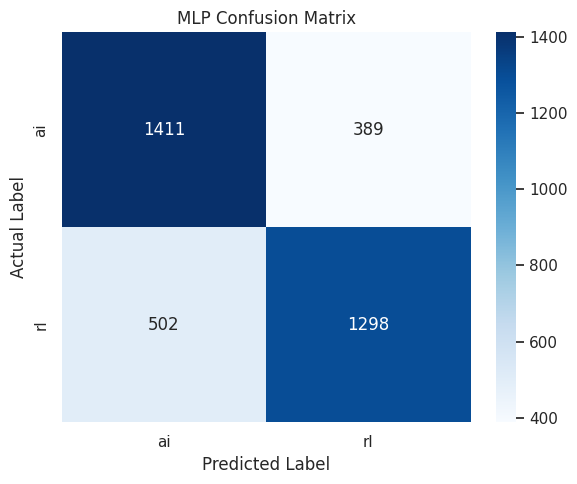


MLP Confusion Matrix (normalized by actual class):
            Predicted: ai  Predicted: rl
Actual: ai         0.7839         0.2161
Actual: rl         0.2789         0.7211


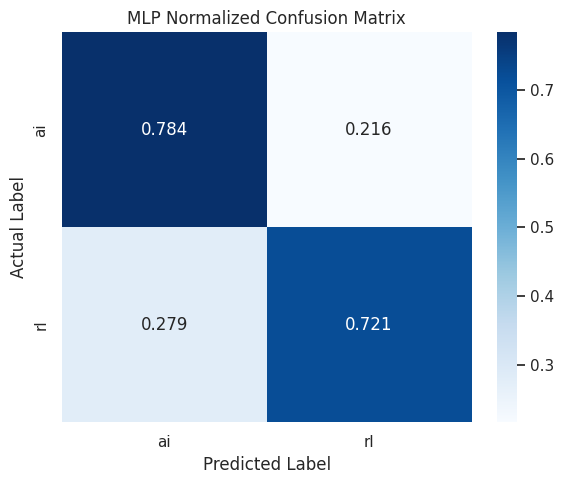


RBF SVM confusion matrix computed successfully.

RBF SVM Confusion Matrix (counts):
            Predicted: ai  Predicted: rl
Actual: ai           1406            394
Actual: rl            364           1436


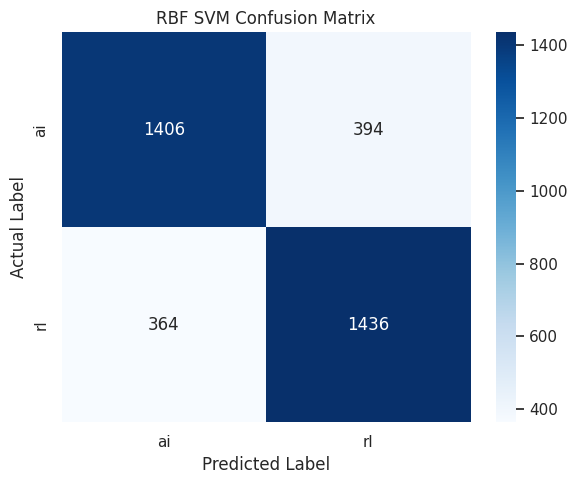


RBF SVM Confusion Matrix (normalized by actual class):
            Predicted: ai  Predicted: rl
Actual: ai         0.7811         0.2189
Actual: rl         0.2022         0.7978


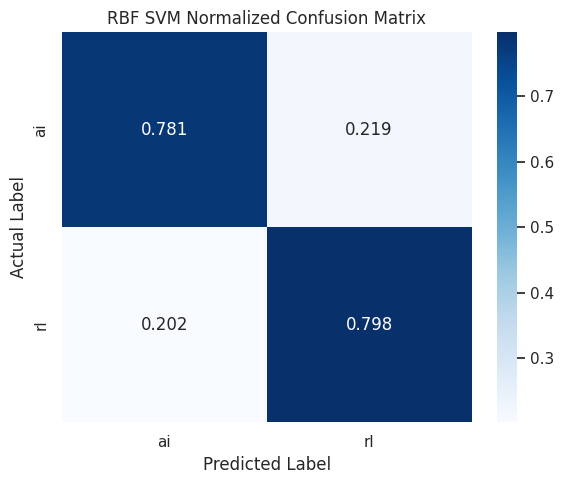

In [22]:
# ============================================================
# Cell 6: Generate and Display Confusion Matrix
# ============================================================

# ============================================================
# MLP Confusion Matrix
# ============================================================

# ------------------------------------------------------------
# Compute confusion matrix
# ------------------------------------------------------------
cm_mlp = confusion_matrix(
    y_test,
    y_pred_mlp,
    labels=CLASS_LABELS
)

print("MLP confusion matrix computed successfully.\n")

# ------------------------------------------------------------
# Display confusion matrix (raw values)
# ------------------------------------------------------------
cm_mlp_df = pd.DataFrame(
    cm_mlp,
    index=[f"Actual: {label}" for label in CLASS_LABELS],
    columns=[f"Predicted: {label}" for label in CLASS_LABELS]
)

print("MLP Confusion Matrix (counts):")
print(cm_mlp_df)

# ------------------------------------------------------------
# Plot confusion matrix (heatmap)
# ------------------------------------------------------------
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_mlp,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_LABELS,
    yticklabels=CLASS_LABELS
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("MLP Confusion Matrix")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Compute normalized confusion matrix (row-wise)
# ------------------------------------------------------------
cm_mlp_normalized = cm_mlp.astype("float") / cm_mlp.sum(axis=1, keepdims=True)

cm_mlp_norm_df = pd.DataFrame(
    cm_mlp_normalized,
    index=[f"Actual: {label}" for label in CLASS_LABELS],
    columns=[f"Predicted: {label}" for label in CLASS_LABELS]
)

print("\nMLP Confusion Matrix (normalized by actual class):")
print(cm_mlp_norm_df.round(4))

# ------------------------------------------------------------
# Plot normalized confusion matrix
# ------------------------------------------------------------
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_mlp_normalized,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=CLASS_LABELS,
    yticklabels=CLASS_LABELS
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("MLP Normalized Confusion Matrix")
plt.tight_layout()
plt.show()


# ============================================================
# RBF SVM Confusion Matrix
# ============================================================

# ------------------------------------------------------------
# Compute confusion matrix
# ------------------------------------------------------------
cm_rbf = confusion_matrix(
    y_test,
    y_pred_rbf,
    labels=CLASS_LABELS
)

print("\nRBF SVM confusion matrix computed successfully.\n")

# ------------------------------------------------------------
# Display confusion matrix (raw values)
# ------------------------------------------------------------
cm_rbf_df = pd.DataFrame(
    cm_rbf,
    index=[f"Actual: {label}" for label in CLASS_LABELS],
    columns=[f"Predicted: {label}" for label in CLASS_LABELS]
)

print("RBF SVM Confusion Matrix (counts):")
print(cm_rbf_df)

# ------------------------------------------------------------
# Plot confusion matrix (heatmap)
# ------------------------------------------------------------
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_rbf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_LABELS,
    yticklabels=CLASS_LABELS
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("RBF SVM Confusion Matrix")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Compute normalized confusion matrix (row-wise)
# ------------------------------------------------------------
cm_rbf_normalized = cm_rbf.astype("float") / cm_rbf.sum(axis=1, keepdims=True)

cm_rbf_norm_df = pd.DataFrame(
    cm_rbf_normalized,
    index=[f"Actual: {label}" for label in CLASS_LABELS],
    columns=[f"Predicted: {label}" for label in CLASS_LABELS]
)

print("\nRBF SVM Confusion Matrix (normalized by actual class):")
print(cm_rbf_norm_df.round(4))

# ------------------------------------------------------------
# Plot normalized confusion matrix
# ------------------------------------------------------------
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_rbf_normalized,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=CLASS_LABELS,
    yticklabels=CLASS_LABELS
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("RBF SVM Normalized Confusion Matrix")
plt.tight_layout()
plt.show()


ROC curves computed successfully.
Number of MLP ROC points: 1181
Number of RBF SVM ROC points: 1055


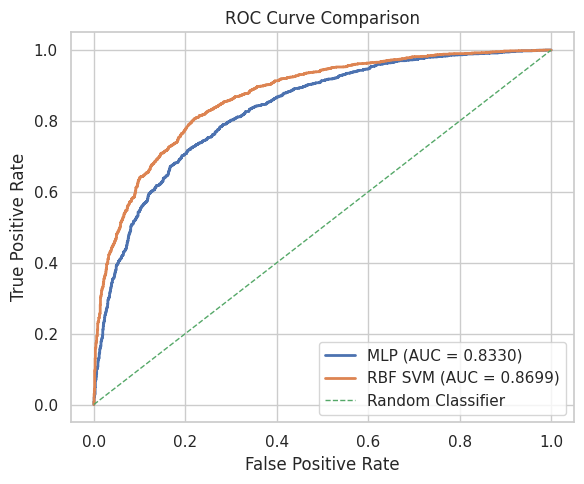


First 10 ROC points (MLP):
   threshold       fpr       tpr
0        inf  0.000000  0.000000
1        1.0  0.000000  0.003889
2        1.0  0.000000  0.007222
3        1.0  0.000556  0.007222
4        1.0  0.000556  0.020556
5        1.0  0.001111  0.020556
6        1.0  0.001111  0.022778
7        1.0  0.001667  0.022778
8        1.0  0.001667  0.027222
9        1.0  0.002222  0.027222

First 10 ROC points (RBF SVM):
   threshold       fpr       tpr
0        inf  0.000000  0.000000
1   0.999995  0.000000  0.000556
2   0.997994  0.000000  0.006111
3   0.997870  0.000556  0.006111
4   0.989550  0.000556  0.030556
5   0.989269  0.001111  0.030556
6   0.985771  0.001111  0.041667
7   0.985731  0.001667  0.041667
8   0.967479  0.001667  0.093333
9   0.967277  0.002222  0.093333


In [23]:
# ============================================================
# Cell 7: Generate and Display ROC Curve
# ============================================================

# ------------------------------------------------------------
# Compute ROC curves
# ------------------------------------------------------------
fpr_mlp, tpr_mlp, thresholds_mlp = roc_curve(y_test_binary, y_score_mlp)
fpr_rbf, tpr_rbf, thresholds_rbf = roc_curve(y_test_binary, y_score_rbf)

print("ROC curves computed successfully.")
print(f"Number of MLP ROC points: {len(fpr_mlp)}")
print(f"Number of RBF SVM ROC points: {len(fpr_rbf)}")

# ------------------------------------------------------------
# Plot ROC curves
# ------------------------------------------------------------
plt.figure(figsize=(6, 5))

plt.plot(
    fpr_mlp,
    tpr_mlp,
    label=f"MLP (AUC = {roc_auc_mlp:.4f})",
    linewidth=2
)

plt.plot(
    fpr_rbf,
    tpr_rbf,
    label=f"RBF SVM (AUC = {roc_auc_rbf:.4f})",
    linewidth=2
)

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Preview first few ROC points
# ------------------------------------------------------------
roc_preview_mlp = pd.DataFrame({
    "threshold": thresholds_mlp[:10],
    "fpr": fpr_mlp[:10],
    "tpr": tpr_mlp[:10]
})

roc_preview_rbf = pd.DataFrame({
    "threshold": thresholds_rbf[:10],
    "fpr": fpr_rbf[:10],
    "tpr": tpr_rbf[:10]
})

print("\nFirst 10 ROC points (MLP):")
print(roc_preview_mlp.round(6))

print("\nFirst 10 ROC points (RBF SVM):")
print(roc_preview_rbf.round(6))



In [24]:
# ============================================================
# Cell 8: Summarize Final Test Results in Tabular Form
# ============================================================

# ------------------------------------------------------------
# Create final results summary table
# ------------------------------------------------------------
df_final_results = pd.DataFrame([
    {
        "model_name": "MLP_128_64_32_alpha0.001.pkl",
        "accuracy": accuracy_mlp,
        "precision": precision_mlp,
        "recall": recall_mlp,
        "f1_score": f1_mlp,
        "roc_auc": roc_auc_mlp
    },
    {
        "model_name": "RBF_SVM_C100_gamma0.01.pkl",
        "accuracy": accuracy_rbf,
        "precision": precision_rbf,
        "recall": recall_rbf,
        "f1_score": f1_rbf,
        "roc_auc": roc_auc_rbf
    }
])

# Sort by ROC-AUC (optional but recommended)
df_final_results = df_final_results.sort_values(by="roc_auc", ascending=False).reset_index(drop=True)

print("Final test-results summary table:\n")
print(df_final_results.round(4))

# ------------------------------------------------------------
# Create report-friendly transposed summary
# ------------------------------------------------------------
df_final_results_transposed = pd.DataFrame({
    "metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "MLP": [
        accuracy_mlp,
        precision_mlp,
        recall_mlp,
        f1_mlp,
        roc_auc_mlp
    ],
    "RBF SVM": [
        accuracy_rbf,
        precision_rbf,
        recall_rbf,
        f1_rbf,
        roc_auc_rbf
    ]
})

print("\nTransposed metric summary:\n")
print(df_final_results_transposed.round(4))

# ------------------------------------------------------------
# Optional: include best model configurations if available
# ------------------------------------------------------------
if best_mlp_config is not None:
    print("\nBest MLP model configuration used for final evaluation:\n")
    print(json.dumps(best_mlp_config, indent=4))
else:
    print("\nBest MLP model configuration not available.")

if best_rbf_config is not None:
    print("\nBest RBF SVM model configuration used for final evaluation:\n")
    print(json.dumps(best_rbf_config, indent=4))
else:
    print("Best RBF SVM model configuration not available.")



Final test-results summary table:

                     model_name  accuracy  precision  recall  f1_score  roc_auc
0    RBF_SVM_C100_gamma0.01.pkl    0.7894     0.7944  0.7811    0.7877   0.8699
1  MLP_128_64_32_alpha0.001.pkl    0.7525     0.7376  0.7839    0.7600   0.8330

Transposed metric summary:

      metric     MLP  RBF SVM
0   Accuracy  0.7525   0.7894
1  Precision  0.7376   0.7944
2     Recall  0.7839   0.7811
3   F1-score  0.7600   0.7877
4    ROC-AUC  0.8330   0.8699

Best MLP model configuration used for final evaluation:

{
    "model_name": "MLP_128_64_32_alpha0.001",
    "model_type": "MLP",
    "hyperparameters": {
        "hidden_layer_sizes": [
            128,
            64,
            32
        ],
        "alpha": 0.001,
        "max_iter": 300,
        "random_state": 42
    },
    "num_features": 25,
    "k_folds": 5,
    "train_samples": 14400,
    "test_samples": 3600,
    "selected_metric": "roc_auc",
    "roc_auc_mean": 0.8373714795524692
}

Best RBF SVM m

In [25]:
# ============================================================
# Cell 9: Save Final Evaluation Outputs
# ============================================================

# ------------------------------------------------------------
# Define output file paths
# ------------------------------------------------------------
FINAL_RESULTS_CSV_PATH = os.path.join(METADATA_DIR, FINAL_RESULTS_FILENAME)
FINAL_RESULTS_JSON_PATH = os.path.join(METADATA_DIR, FINAL_RESULTS_JSON_FILENAME)

CONFUSION_MATRIX_MLP_CSV_PATH = os.path.join(METADATA_DIR, "confusion_matrix_mlp.csv")
CONFUSION_MATRIX_RBF_CSV_PATH = os.path.join(METADATA_DIR, "confusion_matrix_rbf_svm.csv")

ROC_POINTS_MLP_CSV_PATH = os.path.join(METADATA_DIR, "roc_points_mlp.csv")
ROC_POINTS_RBF_CSV_PATH = os.path.join(METADATA_DIR, "roc_points_rbf_svm.csv")

# ------------------------------------------------------------
# Save final metric summary table
# ------------------------------------------------------------
df_final_results.to_csv(FINAL_RESULTS_CSV_PATH, index=False)
print(f"Saved final results CSV: {FINAL_RESULTS_CSV_PATH}")

# ------------------------------------------------------------
# Save final metrics dictionary as JSON
# ------------------------------------------------------------
final_metrics = {
    "MLP": final_metrics_mlp,
    "RBF_SVM": final_metrics_rbf
}

with open(FINAL_RESULTS_JSON_PATH, "w") as f:
    json.dump(final_metrics, f, indent=4)

print(f"Saved final results JSON: {FINAL_RESULTS_JSON_PATH}")

# ------------------------------------------------------------
# Save confusion matrices
# ------------------------------------------------------------
cm_mlp_df.to_csv(CONFUSION_MATRIX_MLP_CSV_PATH)
print(f"Saved MLP confusion matrix CSV: {CONFUSION_MATRIX_MLP_CSV_PATH}")

cm_rbf_df.to_csv(CONFUSION_MATRIX_RBF_CSV_PATH)
print(f"Saved RBF SVM confusion matrix CSV: {CONFUSION_MATRIX_RBF_CSV_PATH}")

# ------------------------------------------------------------
# Save ROC curve points
# ------------------------------------------------------------
df_roc_mlp = pd.DataFrame({
    "threshold": thresholds_mlp,
    "fpr": fpr_mlp,
    "tpr": tpr_mlp
})

df_roc_rbf = pd.DataFrame({
    "threshold": thresholds_rbf,
    "fpr": fpr_rbf,
    "tpr": tpr_rbf
})

df_roc_mlp.to_csv(ROC_POINTS_MLP_CSV_PATH, index=False)
print(f"Saved MLP ROC curve points CSV: {ROC_POINTS_MLP_CSV_PATH}")

df_roc_rbf.to_csv(ROC_POINTS_RBF_CSV_PATH, index=False)
print(f"Saved RBF SVM ROC curve points CSV: {ROC_POINTS_RBF_CSV_PATH}")



Saved final results CSV: /content/drive/MyDrive/DIP_Project/data/metadata/final_test_results.csv
Saved final results JSON: /content/drive/MyDrive/DIP_Project/data/metadata/final_test_results.json
Saved MLP confusion matrix CSV: /content/drive/MyDrive/DIP_Project/data/metadata/confusion_matrix_mlp.csv
Saved RBF SVM confusion matrix CSV: /content/drive/MyDrive/DIP_Project/data/metadata/confusion_matrix_rbf_svm.csv
Saved MLP ROC curve points CSV: /content/drive/MyDrive/DIP_Project/data/metadata/roc_points_mlp.csv
Saved RBF SVM ROC curve points CSV: /content/drive/MyDrive/DIP_Project/data/metadata/roc_points_rbf_svm.csv
